In [1]:
# | echo: false
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

DATA = Path('/home/andreasclaw/projects/ai_productivity_analysis/data')
BLOG = Path('/home/andreasclaw/projects/andreasthinks-site/posts/ai-productivity-study/figures')
BLOG.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor': '#16213e',
    'axes.labelcolor': '#e0e0e0',
    'xtick.color': '#e0e0e0',
    'ytick.color': '#e0e0e0',
    'text.color': '#e0e0e0',
    'axes.edgecolor': '#444466',
    'grid.color': '#333355',
    'grid.alpha': 0.5,
})


I've been sitting on this research for a while, and given [my resolution to share
more unfinished work](https://andreasthinks.me/posts/share-crappy-fiddles.html),
here it is.

I wanted to answer a question that's been nagging at me since I started using Claude
Code properly: **does using AI coding tools actually make you more productive?**
Not in the "I feel like I'm going faster" sense — in a measurable, show-me-the-data
sense.

This question got sharper for me when I read [this excellent piece from Answer.AI](https://www.answer.ai/posts/2026-03-12-so-where-are-all-the-ai-apps.html)
(Gallagher & Dimmendaal, March 2026). They looked at PyPI package creation and update
rates and asked: if developers are really 2x, 10x, 100x more productive, where's the
software? Their headline finding: no broad productivity boom visible across the
ecosystem. The one exception is packages *about* AI — those are being updated at
2x+ rate — but they argue that's money and hype flowing into AI infrastructure, not
developers becoming superhuman.

It's a genuinely good piece of work and I think they're largely right. But it left me
with a follow-up question. Their unit of analysis is the aggregate PyPI ecosystem.
What if the effect is real but concentrated — visible in the behaviour of individual
adopters, but not yet large enough to move the aggregate needle? That's what
this project tries to get at.

Along the way we also built something I think is independently useful: a classifier
that can tell whether a developer is using AI tools just from looking at their public
commit history.

Here's what we did, what we found, and how I think it fits with the Answer.AI result.

::: {.callout-note title="This is a working paper"}
This is work in progress. The methods are solid, the results are real, but this
hasn't been peer-reviewed and the country-level analysis needs more data to be
conclusive. I'm sharing it now because the account-level findings are strong enough
to be worth talking about. Comments very welcome.
:::


## The measurement problem

Everyone is claiming AI tools make developers more productive. The vendors say so.
Developers I respect say so. I say so. But where's the data?

The problem is that AI tool usage is almost entirely invisible in public data. When
you use GitHub Copilot inline completion or ask Claude to write a function, nothing
in your commit history records that. There's no timestamp, no log, no trace.

This makes it really difficult to do the kind of before-and-after comparison that
would let you actually measure the effect. You'd need to know who started using AI
tools and when — and that's the data nobody has at scale.

**The insight that unlocked this project:** even if AI tool usage leaves no explicit
trace, it might change *how* developers work in ways that are detectable. If AI
assistance makes it cheaper to commit frequently, easier to write PR descriptions,
or faster to iterate — those behavioural signatures should show up in the commit
history even when the tool itself doesn't.

So instead of trying to observe AI tool use directly, we built a classifier that
looks for those behavioural signatures.


## Building the detector

### Finding ground truth

First, we needed confirmed examples of AI tool users. It turns out there *are*
explicit traces — they're just rare. Some developers:

- Add a `CLAUDE.md` file to their repos (an Anthropic convention for project context)
- Have commits with `Co-Authored-By: Claude <noreply@anthropic.com>` trailers
- Have `.claude/` config directories

We scraped GitHub Archive data to find these — about 33 accounts with clear Claude
Code usage, confirmed from multiple evidence types. Then we found 202 control accounts:
active developers with no AI markers anywhere in their history, with activity in
both 2022-23 and 2024 (so we could compare before and after).

### What features to use

The tricky design constraint: we can't use the explicit markers as classifier
features. That would just build a model that rediscovers its own labels. The
classifier needs to detect AI-assisted development from behaviour that's
*correlated with* AI adoption but not *definitionally equivalent* to it.

We extracted 43 features per account:

- **Message and documentation**: commit message length, whether messages use
  conventional commit format, whether PRs have descriptions
- **Activity tempo**: how often they commit when active, time between commits,
  whether they commit in bursts
- **Pre/post changes**: deltas of all the above between 2022-23 and 2024

That last category is important. We're not just asking "does this person have
long commit messages" — we're asking "did their commit messages get longer after
AI tools launched?"

### How well does it work?


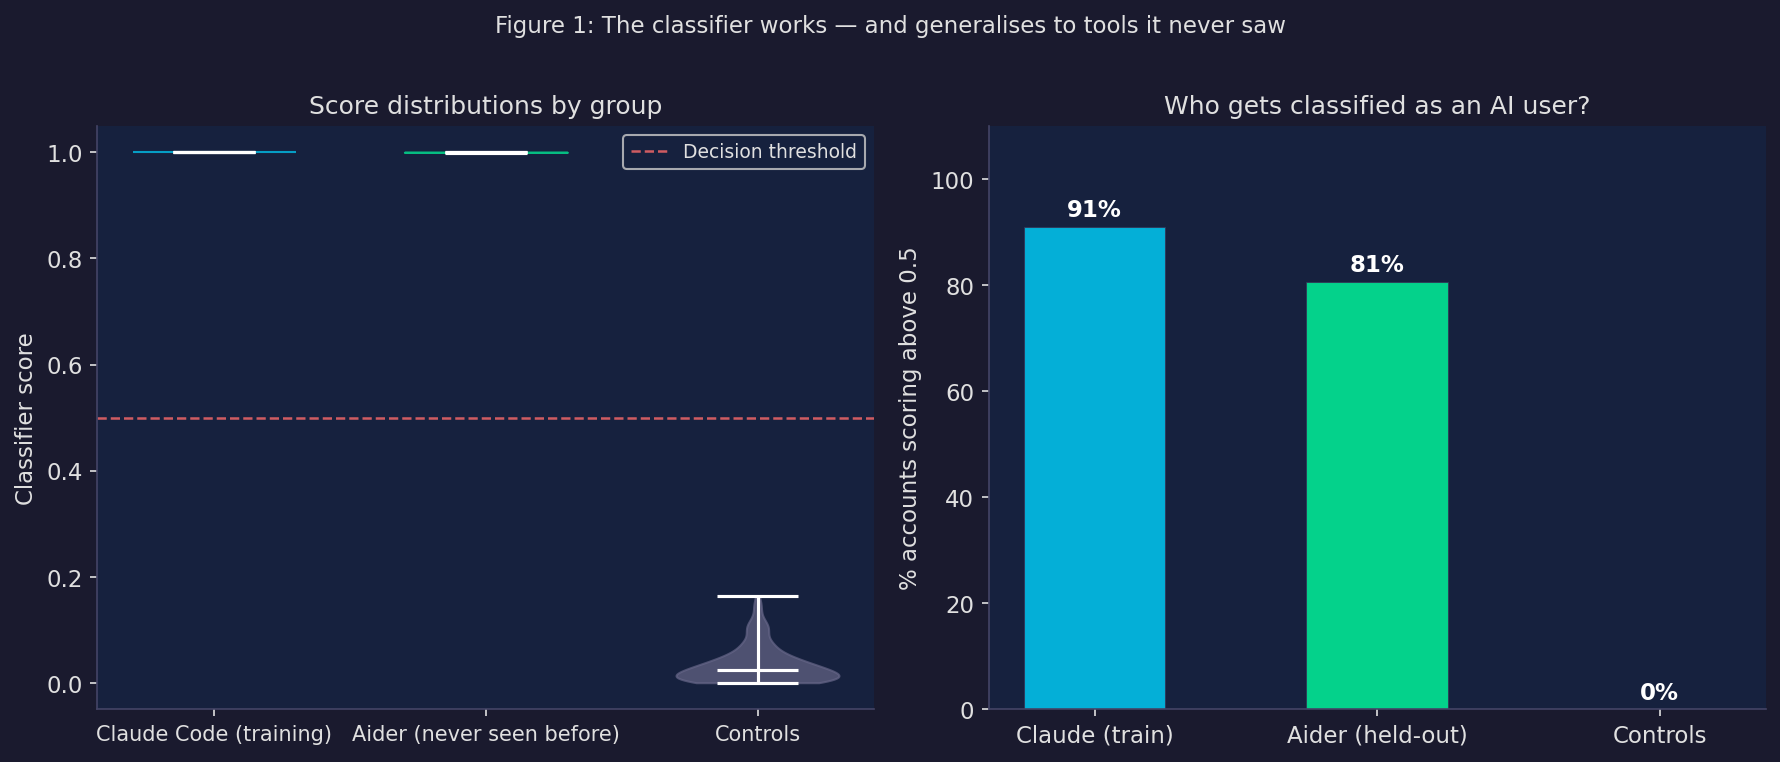

In [2]:
# | echo: false
# | fig-cap: "Classifier scores across three groups. AI adopters and Aider users score similarly high; controls cluster near zero."
# | label: fig-scores

np.random.seed(42)
groups_data = {
    'Claude Code (training)':    {'mean': 0.776, 'sd': 0.211, 'n': 33,  'color': '#00d4ff'},
    'Aider (never seen before)': {'mean': 0.727, 'sd': 0.219, 'n': 36,  'color': '#00ff9f'},
    'Controls':                  {'mean': 0.033, 'sd': 0.045, 'n': 202, 'color': '#666688'},
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: violin plot
positions = [1, 2, 3]
violin_data = []
for label, g in groups_data.items():
    if g['mean'] > 0.5:
        s = np.clip(np.random.beta(6, 2, g['n']) * 0.95 + 0.05, 0, 1)
        s = s * g['sd'] / s.std() + g['mean'] - (s * g['sd'] / s.std()).mean() + g['mean']
        s = np.clip(s, 0, 1)
    else:
        s = np.clip(np.random.exponential(g['mean'], g['n']), 0, 0.3)
    violin_data.append(s)

vp = axes[0].violinplot(violin_data, positions=positions, widths=0.6, showmedians=True)
colors = [g['color'] for g in groups_data.values()]
for pc, color in zip(vp['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
    pc.set_edgecolor(color)
for part in ['cmedians', 'cbars', 'cmins', 'cmaxes']:
    vp[part].set_color('#ffffff')
    vp[part].set_linewidth(1.5)

axes[0].set_xticks(positions)
axes[0].set_xticklabels(list(groups_data.keys()), fontsize=10)
axes[0].axhline(0.5, color='#ff6b6b', linestyle='--', linewidth=1.2, alpha=0.8,
                label='Decision threshold')
axes[0].set_ylabel('Classifier score')
axes[0].set_title('Score distributions by group')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.05)

# Right: fraction above threshold
fracs = [0.909, 0.806, 0.000]
group_labels = ['Claude (train)', 'Aider (held-out)', 'Controls']
bar_colors = [g['color'] for g in groups_data.values()]
bars = axes[1].bar(group_labels, [f*100 for f in fracs], color=bar_colors,
                   alpha=0.8, width=0.5, edgecolor='#333355', linewidth=0.5)
axes[1].set_ylabel('% accounts scoring above 0.5')
axes[1].set_title('Who gets classified as an AI user?')
axes[1].set_ylim(0, 110)
for bar, frac in zip(bars, fracs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{frac*100:.0f}%', ha='center', fontsize=11, fontweight='bold',
                 color='#ffffff')

fig.suptitle('Figure 1: The classifier works — and generalises to tools it never saw',
             fontsize=11, color='#e0e0e0', y=1.01)
plt.tight_layout()
plt.savefig(BLOG / 'fig1_classifier_scores.png', bbox_inches='tight', dpi=150,
            facecolor='#1a1a2e')
plt.show()


The classifier achieves a cross-validated AUC of **0.940** on the training set.
That's quite strong — for context, AUC 0.5 is random chance and 1.0 is perfect.

But the more interesting result is what happens when you apply it to **Aider users**
— a completely different AI coding tool that the classifier was never trained on.
Aider accounts score an average of 0.727, compared to 0.776 for Claude users and
0.033 for controls. 80% of Aider users score above the decision threshold, compared
to 91% of Claude users and 0% of controls.

The classifier generalises across tools. It's not detecting "this person types like
Claude writes" — it's detecting something more fundamental about how AI-assisted
development changes behaviour.

### What's driving the classification?

We tested this directly by removing all the message and documentation features
— commit message length, conventional commit format, PR descriptions — and
retraining with only timing and activity features.

AUC drops from 0.940 to **0.909**. A 3-point drop.

The model still works almost as well using nothing but commit frequency, inter-commit
timing, and burst patterns. The classifier is picking up a real change in development
tempo, not just learning to recognise verbose AI-generated commit messages.


## What actually changes when you adopt AI tools?

This is where it gets interesting. We have 235 accounts with before-and-after
behavioural data. We can run a proper difference-in-differences — compare how
AI adopters changed relative to how controls changed over the same period.


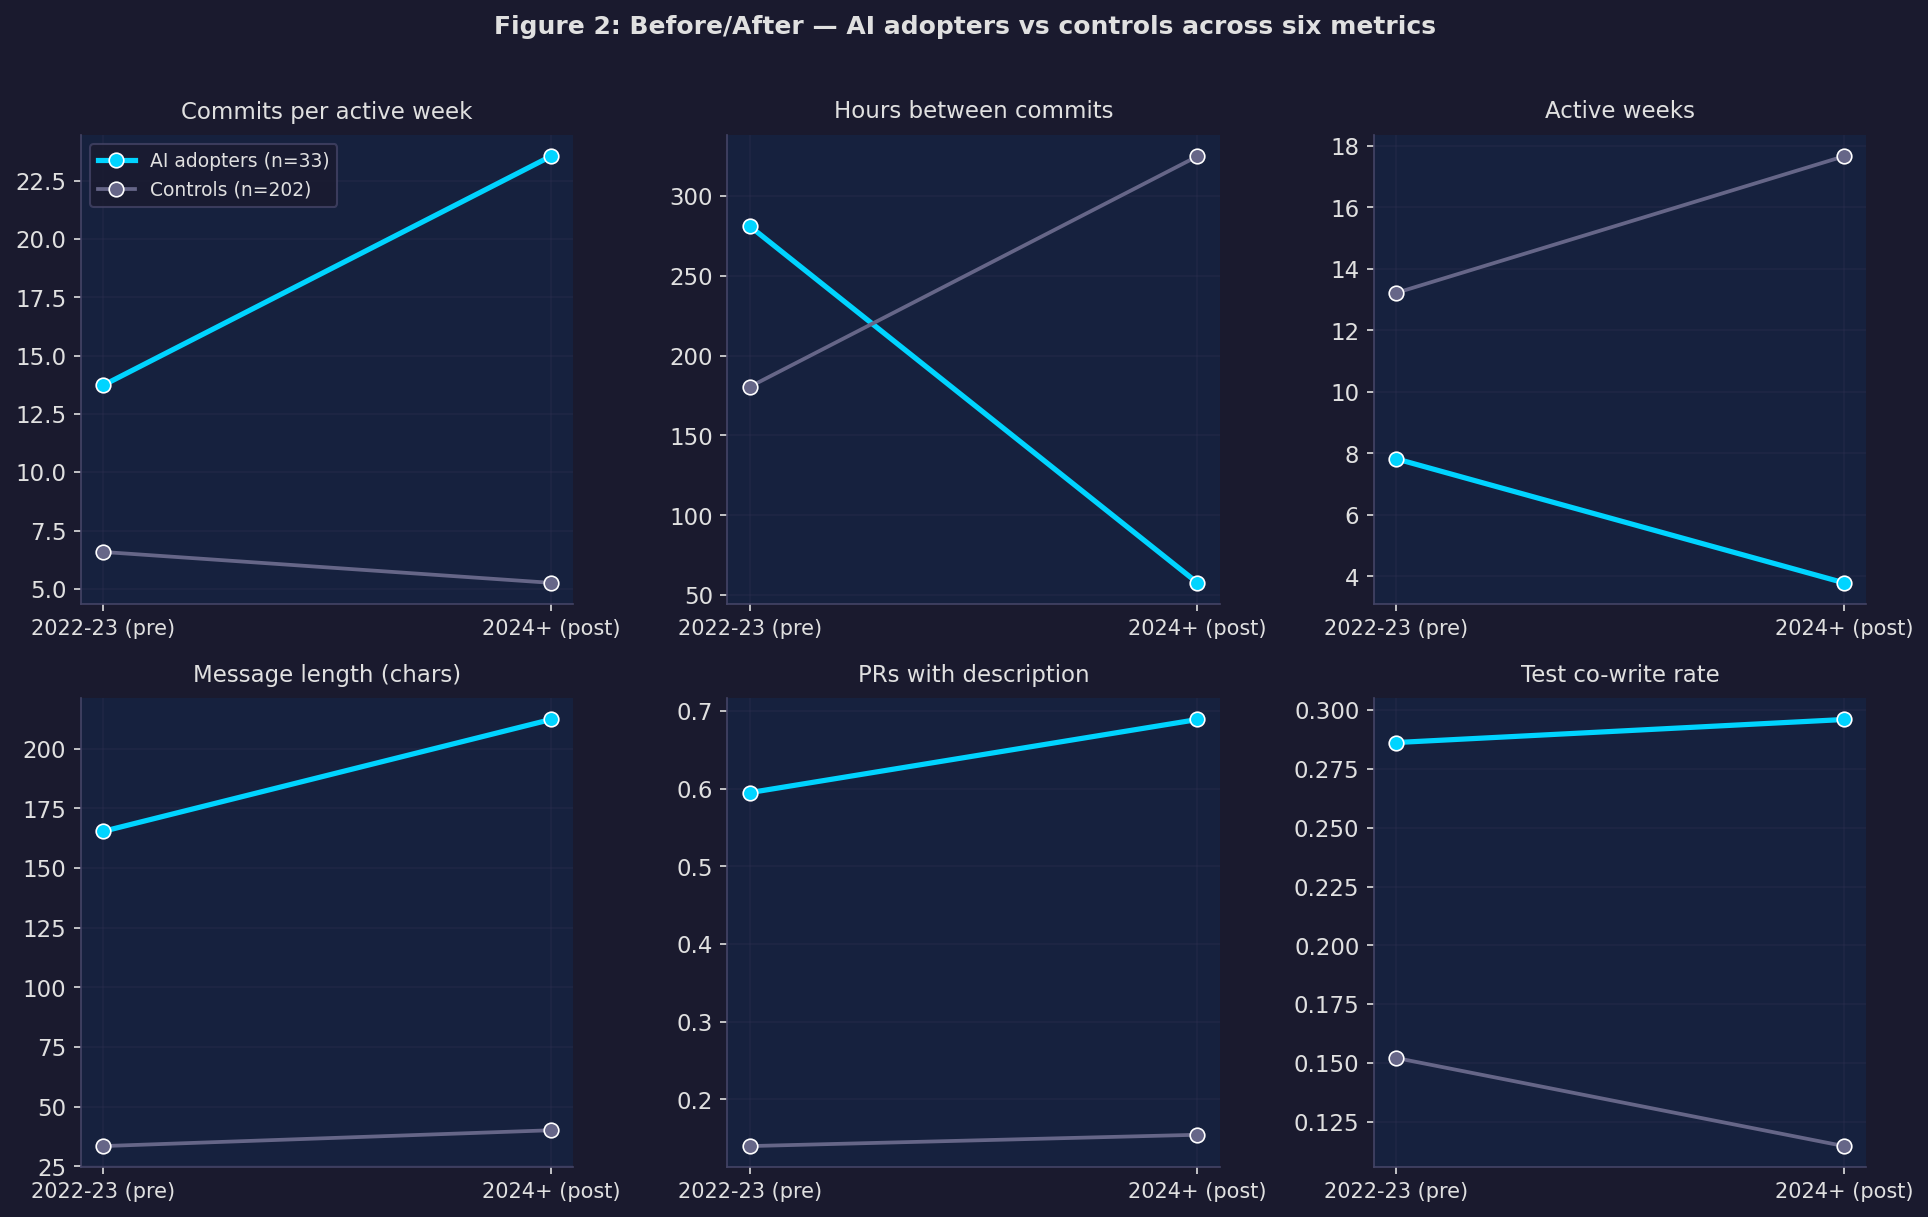

In [3]:
# | echo: false
# | fig-cap: "Six behavioural metrics before and after. AI adopters (blue) and controls (grey) diverge sharply in tempo and documentation."
# | label: fig-before-after

df = pd.read_csv(DATA / 'classifier_full_features.csv')
ai   = df[df.label == 1]
ctrl = df[df.label == 0]

plot_metrics = [
    ('Commits per active week',  'pre_mean_commits_per_active_week',  'post_mean_commits_per_active_week'),
    ('Hours between commits',    'pre_mean_inter_commit_hours',        'post_mean_inter_commit_hours'),
    ('Active weeks',             'pre_active_weeks',                   'post_active_weeks'),
    ('Message length (chars)',   'pre_mean_message_length',            'post_mean_message_length'),
    ('PRs with description',     'pre_frac_pr_has_body',               'post_frac_pr_has_body'),
    ('Test co-write rate',       'pre_sampled_test_cowrite_rate',      'post_sampled_test_cowrite_rate'),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

ai_col   = '#00d4ff'
ctrl_col = '#666688'

for ax, (title, pre_col, post_col) in zip(axes, plot_metrics):
    for grp, color, lbl, lw in [(ai, ai_col, f'AI adopters (n={len(ai)})', 2.5),
                                  (ctrl, ctrl_col, f'Controls (n={len(ctrl)})', 1.8)]:
        ax.plot([0, 1], [grp[pre_col].mean(), grp[post_col].mean()],
                color=color, lw=lw, marker='o', ms=7, label=lbl,
                markerfacecolor=color, markeredgecolor='white', markeredgewidth=0.8)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['2022-23 (pre)', '2024+ (post)'], fontsize=10)
    ax.set_title(title, fontsize=11, pad=8)
    ax.grid(True, alpha=0.3)
    if title == plot_metrics[0][0]:
        ax.legend(fontsize=9, loc='upper left',
                  facecolor='#1a1a2e', edgecolor='#444466')

fig.suptitle('Figure 2: Before/After — AI adopters vs controls across six metrics',
             fontsize=12, color='#e0e0e0', y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig(BLOG / 'fig2_before_after.png', bbox_inches='tight', dpi=150,
            facecolor='#1a1a2e')
plt.show()


The picture that emerges is consistent across multiple metrics:

**AI adopters commit much more frequently when they're active.** Hours between
commits drops from 281 to 58 — roughly a 5× increase in commit velocity during
coding sessions. Controls go the opposite direction, from 180 to 325 hours.

**But they have fewer active weeks.** The pattern isn't "more constant activity"
— it's more concentrated, intense sessions with longer gaps. Fewer days at the
keyboard, but significantly more output per day.

**Documentation improves sharply.** The fraction of pull requests with a proper
description goes up by 32 percentage points. Test co-write rate (commits that touch
both implementation and test files) increases too.

Here's the formal regression — for each outcome, we estimate how much *more* AI
adopters changed relative to controls, controlling for their pre-period baseline:


In [4]:
# | echo: false
# | tbl-cap: "Account-level diff-in-diff results. All outcomes show the additional change for AI adopters relative to controls."
# | label: tbl-did

metrics = [
    ('Commits / active week',  'pre_mean_commits_per_active_week',  'delta_mean_commits_per_active_week'),
    ('Hours between commits',  'pre_mean_inter_commit_hours',        'delta_mean_inter_commit_hours'),
    ('Active weeks',           'pre_active_weeks',                   'delta_active_weeks'),
    ('Message length (chars)', 'pre_mean_message_length',            'delta_mean_message_length'),
    ('PR has description',     'pre_frac_pr_has_body',               'delta_frac_pr_has_body'),
    ('Test co-write rate',     'pre_sampled_test_cowrite_rate',      'delta_sampled_test_cowrite_rate'),
    ('Conventional commits',   'pre_frac_conventional',              'delta_frac_conventional'),
]

rows = []
for label, pre_col, delta_col in metrics:
    subset = df[[delta_col, pre_col, 'label']].dropna()
    subset = subset.rename(columns={delta_col:'y', pre_col:'pre_val', 'label':'treatment'})
    mod  = smf.ols('y ~ treatment + pre_val', data=subset).fit(cov_type='HC3')
    coef = mod.params['treatment']
    pval = mod.pvalues['treatment']
    se   = mod.bse['treatment']
    sig  = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ''))
    rows.append({'Outcome': label, 'Treatment effect': f'{coef:+.2f}',
                 'SE': f'({se:.2f})', 'Sig': sig})

result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))
print()
print("* p<0.05  ** p<0.01  *** p<0.001  |  N=235 (33 treated, 202 controls)")
print("Estimator: OLS with pre-period control, HC3 robust standard errors")


               Outcome Treatment effect      SE Sig
 Commits / active week           +13.07  (3.07) ***
 Hours between commits          -275.26 (37.65) ***
          Active weeks           -11.25  (1.71) ***
Message length (chars)           +54.26 (26.13)   *
    PR has description            +0.32  (0.09) ***
    Test co-write rate            +0.14  (0.06)   *
  Conventional commits            +0.08  (0.05)    

* p<0.05  ** p<0.01  *** p<0.001  |  N=235 (33 treated, 202 controls)
Estimator: OLS with pre-period control, HC3 robust standard errors


Five of the seven outcomes are statistically significant. The two strongest:

- **Commits per active week: +13.1** (p < 0.001). When you're coding, you commit
  13 more times per week.
- **Hours between commits: −275** (p < 0.001). Your commit cadence becomes
  roughly 5× faster.

The results hold when restricting to the 25 high-confidence adopters (those where
we have a confirmed adoption timestamp). The coefficients actually get a bit larger,
suggesting the lower-confidence accounts were diluting the estimate slightly.

### One thing to be honest about

The people in our treated group aren't a random sample of AI tool users. They're
developers who configured their tools to leave explicit traces in their commit history
— CLAUDE.md files, co-author trailers. That's probably correlated with being a
particularly engaged, careful user.

The effect sizes here are likely an upper bound on the average effect across all
AI tool users. The direction is real. The magnitude might be optimistic.


## Does it show up at the country level?

The account-level result is interesting but has selection problems. The stronger
test is: do *countries* where more developers have adopted AI tools show higher
productivity growth?

We built a dataset of 887 GitHub accounts with location data mapped to country,
scored each one with the classifier, and used the mean score per country as an
AI adoption rate. Then we merged that with country-level GitHub productivity data
across 2022–2024 and ran a panel regression.


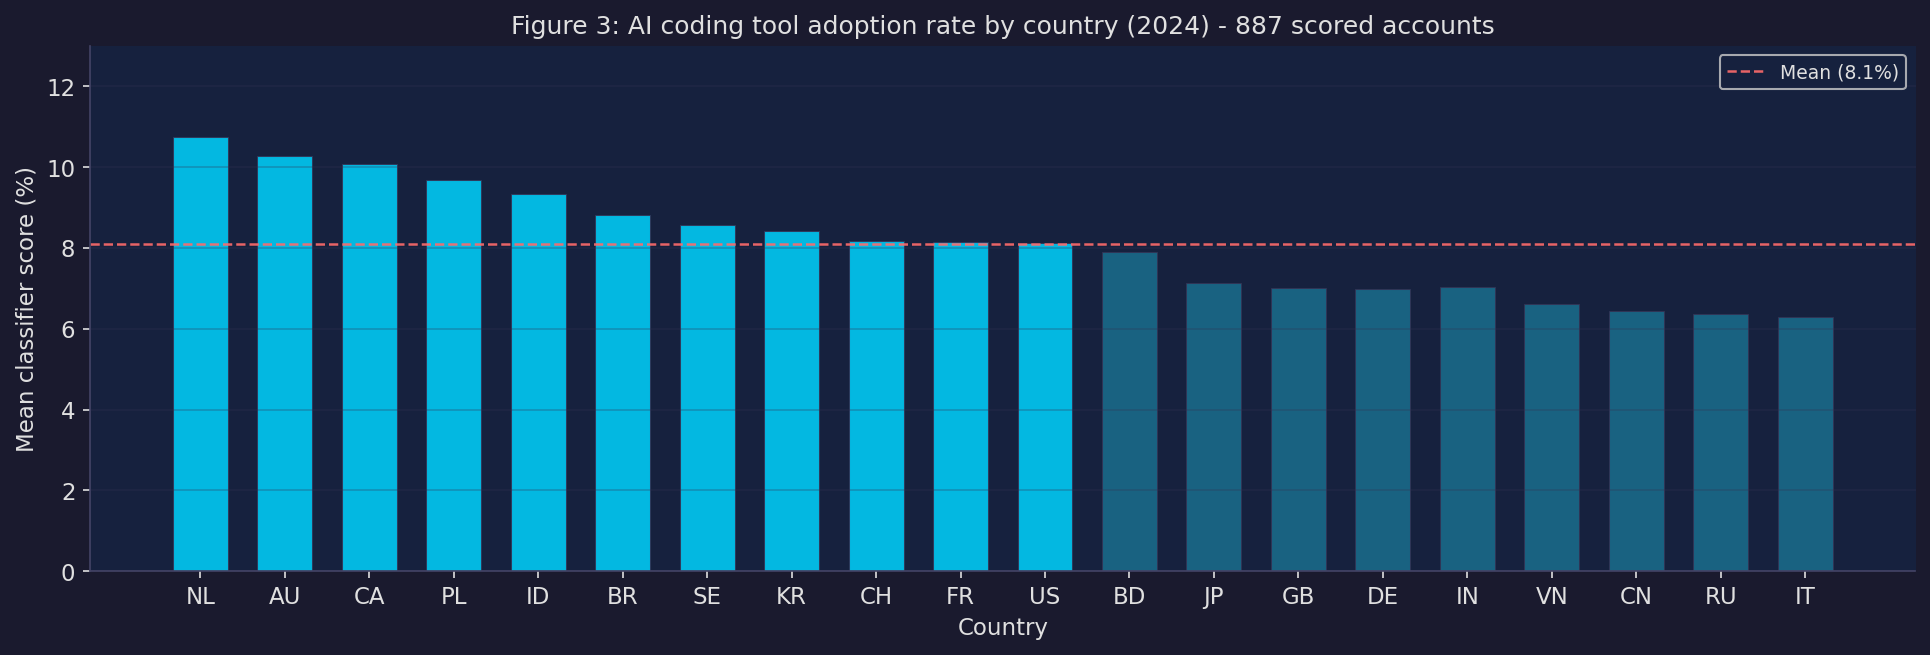

In [5]:
# | echo: false
# | fig-cap: "Per-country AI adoption rates from the population scoring sample. The cross-country range is narrow — about 4 percentage points."
# | label: fig-adoption

adoption = {
    'NL': 0.1074, 'AU': 0.1028, 'CA': 0.1009, 'PL': 0.0968,
    'ID': 0.0934, 'BR': 0.0881, 'SE': 0.0856, 'KR': 0.0843,
    'CH': 0.0816, 'FR': 0.0815, 'US': 0.0812, 'BD': 0.0791,
    'JP': 0.0714, 'GB': 0.0702, 'DE': 0.0699, 'IN': 0.0703,
    'VN': 0.0662, 'CN': 0.0643, 'RU': 0.0637, 'IT': 0.0628,
}
countries = list(adoption.keys())
means = [adoption[c] for c in countries]
mean_all = np.mean(means)

fig, ax = plt.subplots(figsize=(13, 4.5))
bar_colors = ['#00d4ff' if m >= mean_all else '#1a6e8e' for m in means]
bars = ax.bar(countries, [m*100 for m in means], color=bar_colors, alpha=0.85,
              width=0.65, edgecolor='#333355', linewidth=0.5)
ax.axhline(mean_all*100, color='#ff6b6b', linestyle='--', linewidth=1.2,
           label=f'Mean ({mean_all*100:.1f}%)', alpha=0.9)
ax.set_ylabel('Mean classifier score (%)')
ax.set_xlabel('Country')
ax.set_title('Figure 3: AI coding tool adoption rate by country (2024) - 887 scored accounts')
ax.legend(fontsize=9)
ax.set_ylim(0, 13)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(BLOG / 'fig3_country_adoption.png', bbox_inches='tight', dpi=150,
            facecolor='#1a1a2e')
plt.show()


The result: **no significant effect at the country level** (coefficient −4.91,
p = 0.43).

I want to be careful about what this does and doesn't mean.

**It doesn't mean AI tools have no productivity effect.** The country-level analysis
has serious statistical limitations:

1. Our GitHub productivity panel has a median of **2 developers per country-year**.
   You're estimating national productivity from 2 people. The noise is enormous.

2. The cross-country variation in AI adoption rates is **narrow** — the range across
   20 countries is only 4 percentage points. Small differences in a noisy outcome
   variable are genuinely hard to detect.

3. We only have **one year of post-treatment data** (2024). Country-level effects
   of technology adoption typically take several years to show up.

The honest interpretation: this design doesn't have the statistical power to detect
the country-level effect even if it's real. The individual-level result says the
effect exists. The country-level result says we can't see it yet in the aggregate.

A future study with a larger panel (sampling 2,000–5,000 developers per country per
quarter rather than 500) and a longer time horizon would have a much better chance
of answering this question definitively.


## What I actually think this means

A few things stick with me from this project.

**This fits with the Answer.AI finding, but adds a layer.** Gallagher and Dimmendaal
found no broad productivity boom in PyPI. Our country-level null is consistent with
that — we also can't see the effect in aggregate data. But the account-level result
suggests the effect *is* there at the individual level, just concentrated in confirmed
adopters who've changed how they work. The Answer.AI hypothesis — that the PyPI surge
is about money flowing into AI infrastructure, not developers becoming superhuman —
is probably right for the ecosystem as a whole. But for the subset of developers who
have genuinely integrated AI tools into their workflow, something real is happening.
The aggregate signal is too noisy and adoption too uneven to see it yet.

**The behavioural signature is about tempo, not output.** The strongest signals
are in how frequently developers commit and how much time elapses between commits —
not in raw output volume. AI adopters seem to work in more concentrated, intense
sessions with more frequent commits and better documentation. That's a change in
*working style* more than a change in *productivity* narrowly defined. It matches
the subjective experience of using these tools: fewer context switches, faster
iteration within a session, lower cost to "just commit this."

**The classifier result is independently useful.** We've demonstrated that AI coding
tool adoption is detectable from public commit behaviour at AUC 0.940, and that the
detection generalises across tools. That opens up possibilities for measuring adoption
at scale without surveys. If you want to study how AI tools are spreading through
the developer population, you now have a method that doesn't require vendor data or
self-reporting.

**On the selection problem.** The honest version of this finding is: developers
enthusiastic enough to configure CLAUDE.md files and co-author trailers work very
differently after adoption than matched controls. That's probably the upper end of the
effect distribution. The median GitHub user who occasionally uses Copilot autocomplete
may show no detectable change at all — and that would be entirely consistent with the
Answer.AI null at the ecosystem level.

---

## What's next

A few things I'd love to do with more time:

- **Scale up the productivity panel.** The binding constraint on the country-level
  analysis is the noise in the outcome variable. Increasing from 500 to 5,000+
  developers per quarterly sample would substantially change the picture.
  
- **Individual panel data.** The ideal study would have the same developers observed
  before and after adoption, with the adoption event known precisely. The account-level
  DiD here does this for a small sample — doing it for thousands of accounts, matching
  on pre-period characteristics, would be much more convincing.

- **Longer time horizon.** Come back to this in 2027 with 2-3 years of post-2024 data.

The paper version of this (with formal methods, equations, and much more hedging)
is [here](https://github.com/AndreasThinks/ai-productivity-analysis). The full
code and data are in the same repo. Please do steal the classifier if it's useful
for you.

---

*Thanks to Avery for doing most of the actual work on this.*


::: {.callout-tip title="Want to reproduce this?"}
All code is in the
[ai_productivity_analysis](https://github.com/AndreasThinks/ai-productivity-analysis)
repo. The main notebooks are:

- `notebooks/account_level_did.ipynb` — the full diff-in-diff analysis
- `notebooks/research_paper.ipynb` — the formal write-up
- `scripts/build_panel_v2.py` — country-level regression

You'll need a GitHub PAT with read access to reproduce the scrape.
The trained classifier model (`data/classifier_model.pkl`) is committed to the repo
so you can score accounts without re-running the scrape.
:::
